#  Import des bibliothèques

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import ks_2samp
from sklearn.base import clone
import joblib  # pour charger le modèle sauvegardé


In [7]:
# Données
df_lille = pd.read_csv("../data/df_lille.csv")
df_bordeaux = pd.read_csv("../data/df_bordeaux.csv")


In [9]:
# Variables explicatives et cible


# Variables explicatives et cible
features = ['Surface reelle bati', 'Type local_Maison', 'Surface terrain', 'Nombre de lots']
target = 'prix_m2'

X_lille = df_lille[features]
y_lille = df_lille[[target]]
X_bordeaux = df_bordeaux[features]
y_bordeaux = df_bordeaux[[target]]

KS test for Surface reelle bati: stat = 0.0758, p-value = 0.0000
KS test for Type local_Maison: stat = 0.0002, p-value = 1.0000
KS test for Surface terrain: stat = 0.0676, p-value = 0.0000
KS test for Nombre de lots: stat = 0.1141, p-value = 0.0000


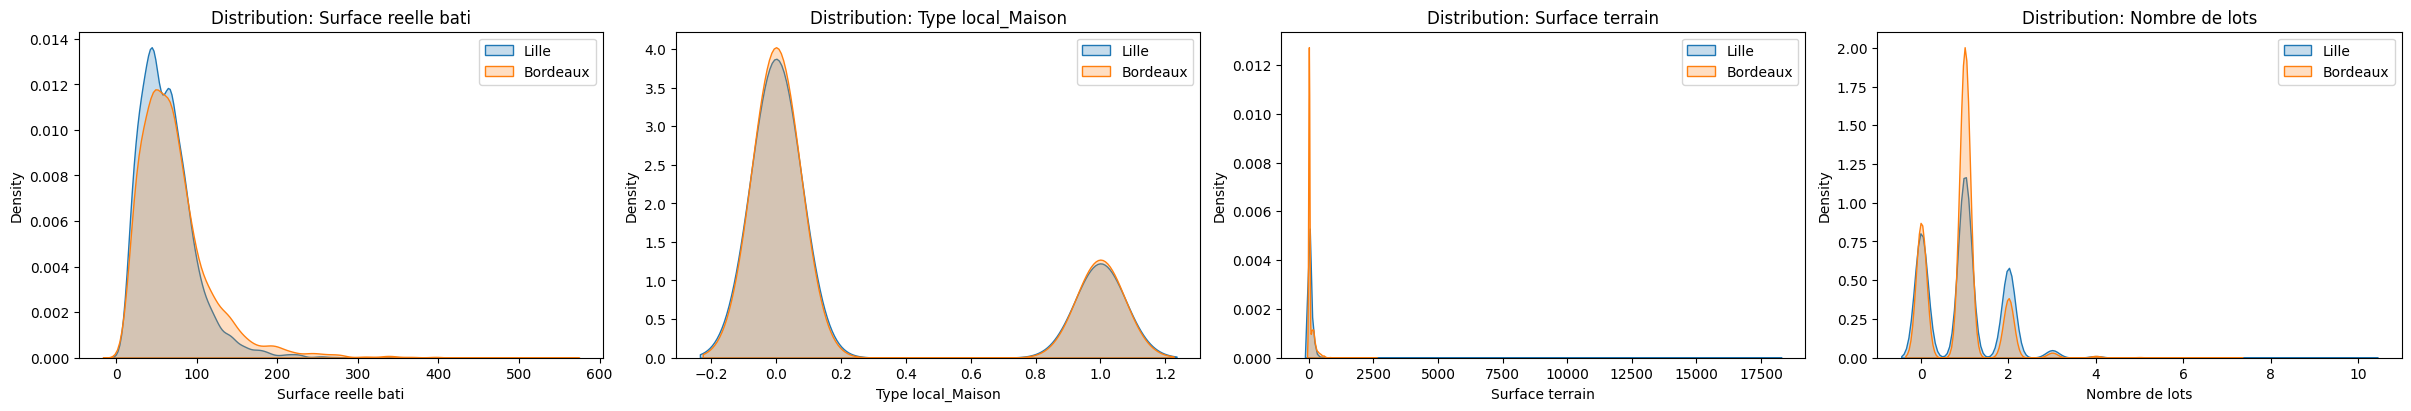

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# Suppose que tu as défini : features = ['feature1', 'feature2', 'feature3', 'feature4']
fig, axes = plt.subplots(1, 4, figsize=(24, 4), constrained_layout=True)

for i, col in enumerate(features):
    ax = axes[i]
    sns.kdeplot(X_lille[col], label='Lille', fill=True, ax=ax)
    sns.kdeplot(X_bordeaux[col], label='Bordeaux', fill=True, ax=ax)
    ax.set_title(f'Distribution: {col}')
    ax.legend()

    stat, p = ks_2samp(X_lille[col], X_bordeaux[col])
    print(f"KS test for {col}: stat = {stat:.4f}, p-value = {p:.4f}")

plt.show()


🧠 Conclusion pratique
Tu peux retenir :

Le test KS indique clairement qu’il faut adapter le modèle au domaine cible (Bordeaux)
❌ Il ne suffit pas de transférer un modèle entraîné uniquement sur Lille sans ajustement.

# Transfert Learning 

In [20]:
#Charger les modèles entraînés sur Lille
all_data = joblib.load("../models/model_lille.pkl")
models_lille = all_data["models"]


In [24]:
# Créer une structure pour stocker les performances
results = []

# 3. Boucle sur chaque modèle
for name, model in models_lille.items():
    print(f"Transfert learning pour {name}...")

    try:
        # Cloner le modèle pour éviter de modifier l'original
        model_cloned = clone(model)

        # Fine-tuning sur les données de Bordeaux
        model_cloned.fit(X_bordeaux, y_bordeaux.values.ravel())

        # Prédictions
        y_pred = model_cloned.predict(X_bordeaux)

        # Évaluation
        mse = mean_squared_error(y_bordeaux, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_bordeaux, y_pred)

        results.append({
            "Modèle": name,
            "MSE": mse,
            "RMSE": rmse,
            "R²": r2
        })

    except Exception as e:
        print(f"Erreur avec le modèle {name} : {e}")

# 4. Résultats sous forme de DataFrame
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="RMSE")

print("\nRésultats après transfert learning (réentraînement sur Bordeaux) :")
print(df_results)

Transfert learning pour Linear Regression...
Transfert learning pour Decision Tree...
Transfert learning pour Random Forest...
Transfert learning pour Random Forest Optimized...
Transfert learning pour XGBoost...

Résultats après transfert learning (réentraînement sur Bordeaux) :
                    Modèle           MSE         RMSE        R²
1            Decision Tree  1.119357e+06  1057.996873  0.568763
2            Random Forest  1.237421e+06  1112.394368  0.523278
4                  XGBoost  1.318570e+06  1148.290251  0.492015
3  Random Forest Optimized  1.598214e+06  1264.205086  0.384281
0        Linear Regression  2.365487e+06  1538.013967  0.088686


📌 Explications des étapes du transfert learning :

Chargement du modèle entraîné à Lille via models_lille.

Clonage du modèle avec clone(model) pour ne pas altérer l’original.

Réentraînement de ce modèle cloné avec les données de Bordeaux → c’est ici que le transfert learning a lieu.


⚠️ Important :
Ce n’est pas un vrai transfert learning dans le sens deep learning, où on gèles des couches et affines certaines. Ici, on parle plutôt de domain adaptation ou de réutilisation de modèle entre régions, ce qui est fréquent en machine learning classique.

Pour RandomForest, DecisionTree, LinearRegression, il n’y a pas de fine-tuning natif : .fit() réentraine depuis zéro.

Pour des modèles comme XGBoost, on peux faire un model.fit(..., xgb_model=model) pour continuer l’apprentissage (vrai transfert learning).

✅ Alternative pertinente
Si l'on souhaite approfondir le transfert entre villes ou intégrer des sources de données hétérogènes (photos, descriptions textuelles, géolocalisation fine), alors le recours à des approches deep learning adaptées aux données tabulaires (comme TabNet, FT-Transformer ou un MLP avec fine-tuning) peut devenir pertinent.

